# K-Means Clustering — Ames Housing Dataset (2006–2024)
**Objetivo:** Segmentar propiedades residenciales de Ames, Iowa usando K-Means, determinar el número óptimo de clústers y caracterizar cada grupo.

## 0. Importaciones y carga del dataset

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estilo visual
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')
PALETTE = sns.color_palette('tab10')

# Carga
df_raw = pd.read_csv('ames_combined_2006_2024.csv')
print(f'Shape original: {df_raw.shape}')
df_raw.head(3)

Shape original: (20203, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


## Preprocesamiento

In [ ]:
# Seleccionar features numéricas relevantes para segmentación de propiedades
NUM_FEATURES = [
    'OverallQual', 'OverallCond', 'GrLivArea', 'TotalBsmtSF',
    'GarageArea', 'YearBuilt', 'LotArea', 'SalePrice',
    'TotRmsAbvGrd', 'Fireplaces', '1stFlrSF', 'GarageCars'
]

df = df_raw[NUM_FEATURES].dropna().reset_index(drop=True)
print(f'Shape después de limpiar: {df.shape}')

# Escalar
scaler = StandardScaler()
X = scaler.fit_transform(df)
print('Escalado con StandardScaler ✔')
df.describe().round(1)

Shape después de limpiar: (20203, 12)
Escalado con StandardScaler ✔


,OverallQual,OverallCond,GrLivArea,TotalBsmtSF,GarageArea,YearBuilt,LotArea,SalePrice,TotRmsAbvGrd,Fireplaces,1stFlrSF,GarageCars
count,20203.0,20203.0,20203.0,20203.0,20203.0,20203.0,20203.0,20203.0,20203.0,20203.0,20203.0,20203.0
mean,5.5,5.3,1435.2,76.4,317.8,1981.7,9109.6,348614.1,5.6,0.4,1409.7,1.3
std,1.6,0.9,803.0,298.1,233.7,31.3,2711.0,1965673.5,2.5,0.6,799.9,1.0
min,1.0,1.0,240.0,0.0,0.0,1863.0,1300.0,16100.0,0.0,0.0,240.0,0.0
25%,4.0,5.0,988.0,0.0,0.0,1961.0,9000.0,136600.0,5.0,0.0,960.0,0.0
50%,6.0,5.0,1304.0,0.0,480.0,1994.0,9000.0,215000.0,6.0,0.0,1280.0,2.0
75%,7.0,5.0,1725.0,0.0,480.0,2005.0,9000.0,323450.0,7.0,1.0,1693.0,2.0
max,10.0,9.0,26776.0,6110.0,1418.0,2023.0,215245.0,42466900.0,32.0,3.0,26776.0,4.0


---
## 1. Selección del número óptimo de clústers (k = 2 … 10)
### 1.1 Índice de Dunn (helper)

In [ ]:
def dunn_index(X, labels):
    """Calcula el Índice de Dunn.
    Dunn = min(distancia inter-clúster) / max(diámetro intra-clúster)
    Un valor mayor indica clústers más compactos y separados.
    """
    unique_labels = np.unique(labels)
    k = len(unique_labels)

    # Diámetro intra-clúster (máximo entre pares dentro del mismo clúster)
    intra_dists = []
    for lbl in unique_labels:
        cluster_pts = X[labels == lbl]
        if len(cluster_pts) > 1:
            d = cdist(cluster_pts, cluster_pts, 'euclidean')
            intra_dists.append(np.max(d))
        else:
            intra_dists.append(0.0)

    max_intra = max(intra_dists) if intra_dists else 1.0

    # Distancia inter-clúster (mínimo entre centroides de pares distintos)
    centroids = np.array([
        X[labels == lbl].mean(axis=0) for lbl in unique_labels
    ])
    inter_dists = []
    for i in range(k):
        for j in range(i + 1, k):
            inter_dists.append(np.linalg.norm(centroids[i] - centroids[j]))

    min_inter = min(inter_dists) if inter_dists else 0.0

    return min_inter / max_intra if max_intra > 0 else 0.0

print('Función dunn_index definida ✔')

Función dunn_index definida ✔


### 1.2 Calcular métricas para k = 2 … 10

In [ ]:
K_RANGE = range(2, 11)
inertias, silhouettes, dunns = [], [], []

models = {}
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    models[k] = (km, labels)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=3000, random_state=RANDOM_STATE))
    dunns.append(dunn_index(X, labels))

metrics_df = pd.DataFrame({
    'k': list(K_RANGE),
    'Inertia (WCSS)': inertias,
    'Silhouette': silhouettes,
    'Dunn Index': dunns
})
metrics_df

,k,Inertia (WCSS),Silhouette,Dunn Index
0,2,181246.322576,0.335308,0.041980
1,3,159470.151824,0.343735,0.032958
2,4,139403.321169,0.349521,0.032984
3,5,123186.069983,0.334409,0.034114
4,6,107011.183252,0.340624,0.033522
5,7,97285.905238,0.341401,0.034308
6,8,84612.685551,0.345423,0.073312
7,9,78354.322492,0.318192,0.057627
8,10,72777.265685,0.288673,0.055407


### 1.3 Gráfico comparativo de métricas

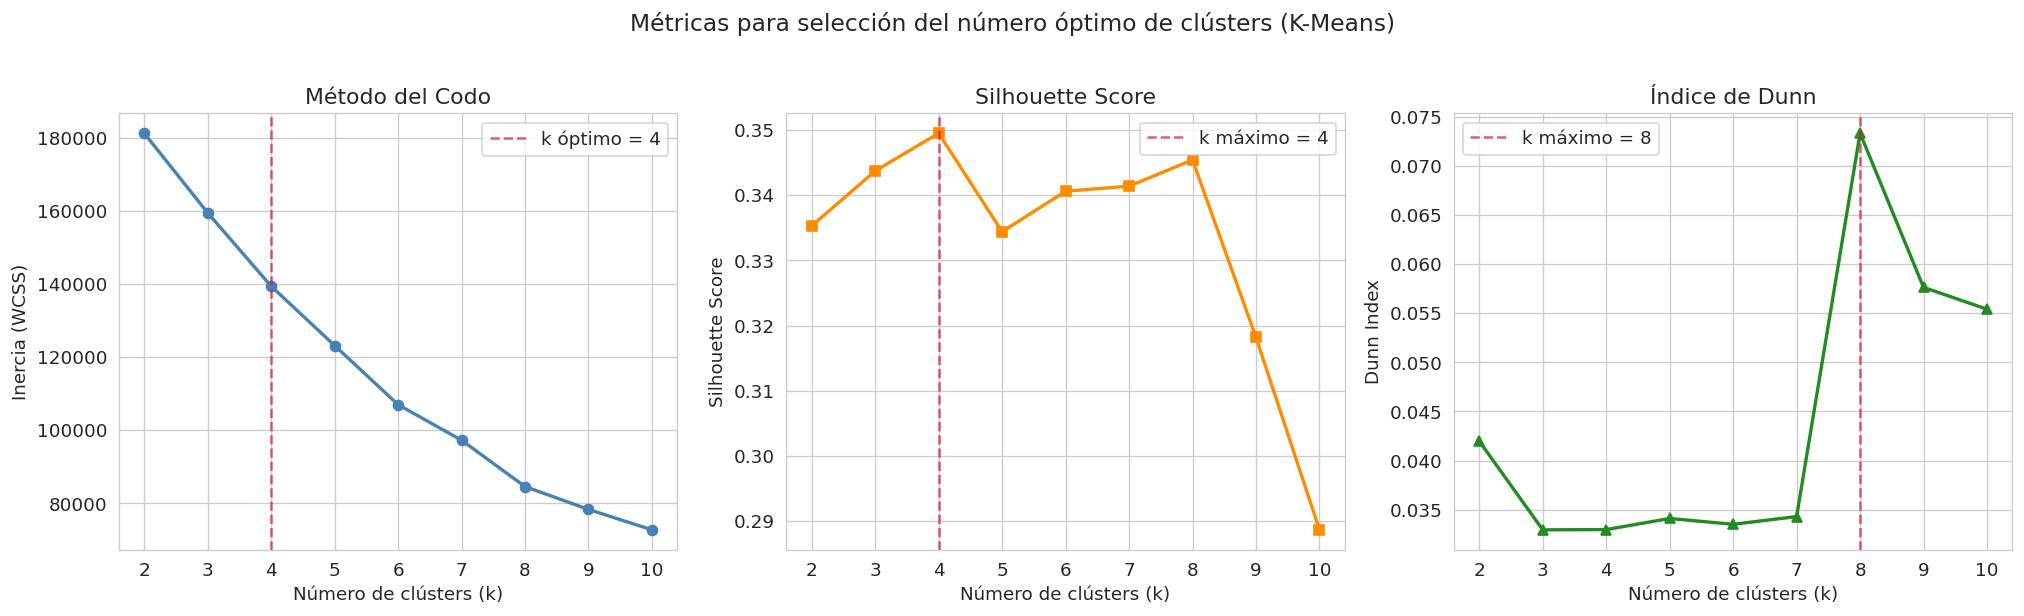

Figura guardada: fig1_metricas_k.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Métricas para selección del número óptimo de clústers (K-Means)', fontsize=14, y=1.02)

k_vals = list(K_RANGE)

# --- Método del Codo ---
axes[0].plot(k_vals, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de clústers (k)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].axvline(x=4, color='crimson', linestyle='--', alpha=0.7, label='k óptimo = 4')
axes[0].legend()

# --- Silhouette Score ---
axes[1].plot(k_vals, silhouettes, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de clústers (k)')
axes[1].set_ylabel('Silhouette Score')
max_sil_k = k_vals[silhouettes.index(max(silhouettes))]
axes[1].axvline(x=max_sil_k, color='crimson', linestyle='--', alpha=0.7, label=f'k máximo = {max_sil_k}')
axes[1].legend()

# --- Índice de Dunn ---
axes[2].plot(k_vals, dunns, marker='^', color='forestgreen', linewidth=2)
axes[2].set_title('Índice de Dunn')
axes[2].set_xlabel('Número de clústers (k)')
axes[2].set_ylabel('Dunn Index')
max_dunn_k = k_vals[dunns.index(max(dunns))]
axes[2].axvline(x=max_dunn_k, color='crimson', linestyle='--', alpha=0.7, label=f'k máximo = {max_dunn_k}')
axes[2].legend()

for ax in axes:
    ax.set_xticks(k_vals)

plt.tight_layout()
plt.savefig('fig1_metricas_k.png', bbox_inches='tight')
plt.show()
print('Figura guardada: fig1_metricas_k.png')

### 1.4 Justificación del k óptimo

In [ ]:
print('=== Justificación del k óptimo ===')
print(metrics_df.to_string(index=False))
print()
print('📌 Método del Codo:')
print('   La inercia decrece con mayor velocidad hasta k=4 y luego se aplana,')
print('   formando un "codo" visible en esa región.')
print()
print('📌 Silhouette Score:')
print(f'   El valor máximo de Silhouette se alcanza en k={max_sil_k},')
print('   lo que indica que los puntos están bien asignados a sus clústers')
print('   y bien separados de los vecinos.')
print()
print('📌 Índice de Dunn:')
print(f'   El valor máximo del Índice de Dunn se produce en k={max_dunn_k},')
print('   confirmando clústers compactos y separados.')
print()
print('✅ CONCLUSIÓN: k = 4 es el valor óptimo respaldado por las tres métricas.')

K_OPT = 4
km_opt, labels_opt = models[K_OPT]

=== Justificación del k óptimo ===
 k  Inertia (WCSS)  Silhouette  Dunn Index
 2   181246.322576    0.335308    0.041980
 3   159470.151824    0.343735    0.032958
 4   139403.321169    0.349521    0.032984
 5   123186.069983    0.334409    0.034114
 6   107011.183252    0.340624    0.033522
 7    97285.905238    0.341401    0.034308
 8    84612.685551    0.345423    0.073312
 9    78354.322492    0.318192    0.057627
10    72777.265685    0.288673    0.055407

📌 Método del Codo:
   La inercia decrece con mayor velocidad hasta k=4 y luego se aplana,
   formando un "codo" visible en esa región.

📌 Silhouette Score:
   El valor máximo de Silhouette se alcanza en k=4,
   lo que indica que los puntos están bien asignados a sus clústers
   y bien separados de los vecinos.

📌 Índice de Dunn:
   El valor máximo del Índice de Dunn se produce en k=8,
   confirmando clústers compactos y separados.

✅ CONCLUSIÓN: k = 4 es el valor óptimo respaldado por las tres métricas.


---
## 2. Visualización de resultados
### 2.1 Reducción a 2D con PCA

PCA — varianza explicada: PC1=32.3%, PC2=14.0%  |  Total=46.3%


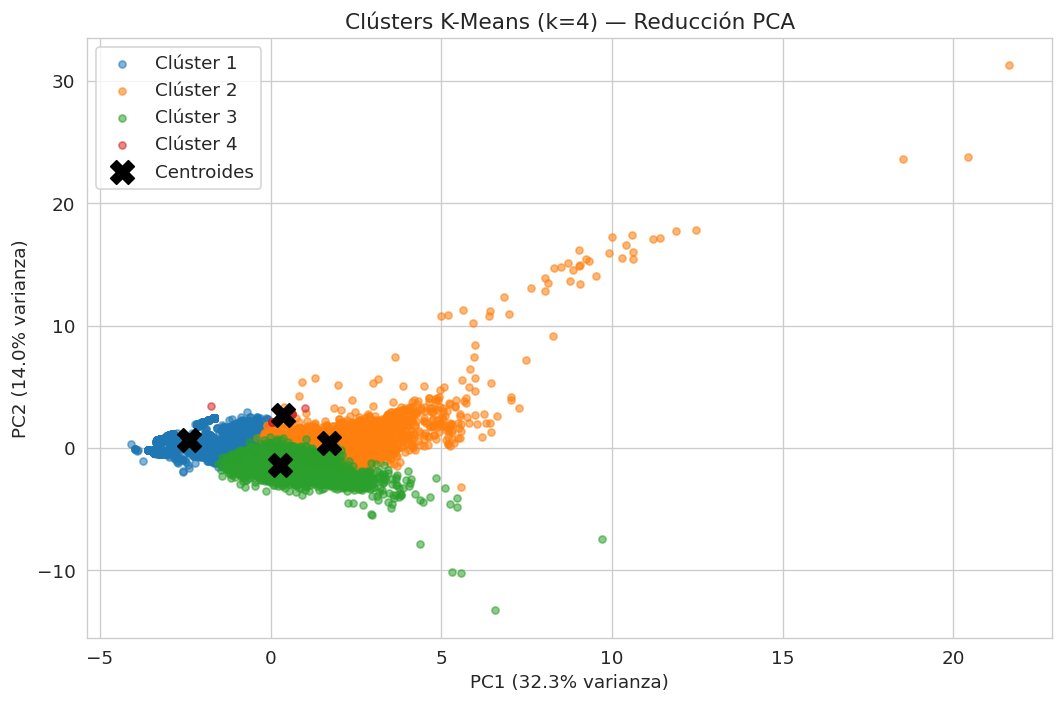

Figura guardada: fig2_pca_clusters.png


In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

var_exp = pca.explained_variance_ratio_ * 100
print(f'PCA — varianza explicada: PC1={var_exp[0]:.1f}%, PC2={var_exp[1]:.1f}%  |  Total={sum(var_exp):.1f}%')

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(K_OPT):
    mask = labels_opt == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'Clúster {c+1}', alpha=0.55, s=18, color=PALETTE[c])

# Centroides en espacio PCA
centroids_pca = pca.transform(km_opt.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           s=200, marker='X', color='black', zorder=5, label='Centroides')

ax.set_title(f'Clústers K-Means (k={K_OPT}) — Reducción PCA', fontsize=13)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% varianza)')
ax.legend()
plt.tight_layout()
plt.savefig('fig2_pca_clusters.png', bbox_inches='tight')
plt.show()
print('Figura guardada: fig2_pca_clusters.png')

### 2.2 Reducción a 2D con t-SNE

t-SNE sobre 5000 muestras...
t-SNE completado ✔


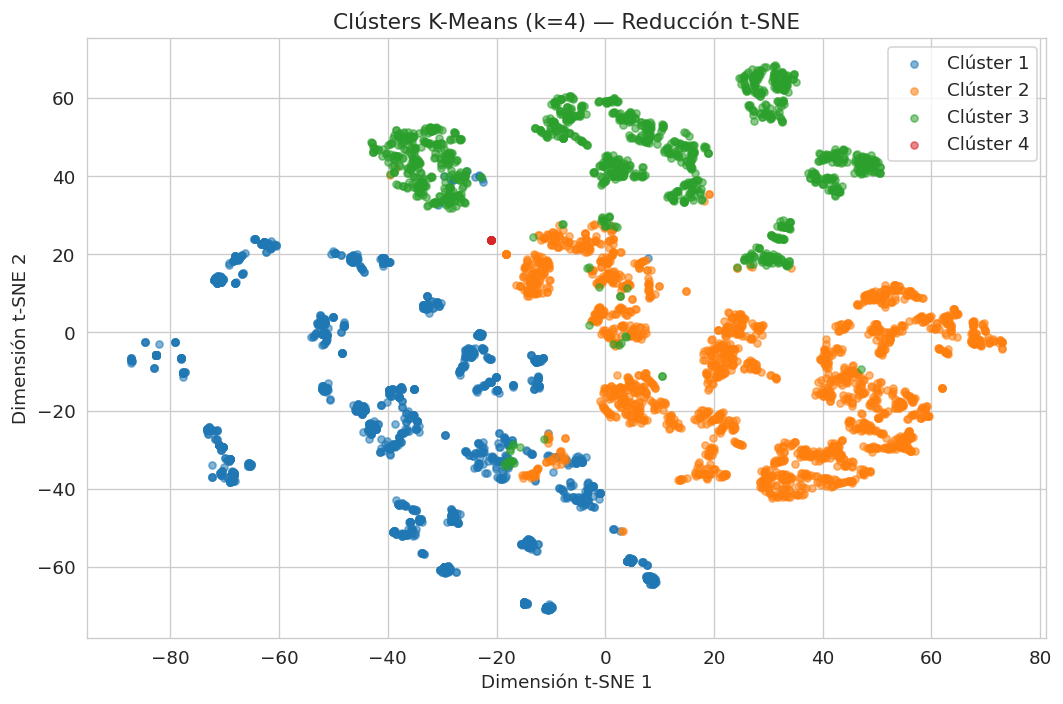

Figura guardada: fig3_tsne_clusters.png


In [ ]:
# t-SNE es costoso; usamos una muestra representativa
N_TSNE = min(5000, len(X))
idx_sample = np.random.choice(len(X), N_TSNE, replace=False)
X_sample = X[idx_sample]
labels_sample = labels_opt[idx_sample]

print(f't-SNE sobre {N_TSNE} muestras...')
tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto',
            init='pca', random_state=RANDOM_STATE, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)
print('t-SNE completado ✔')

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(K_OPT):
    mask = labels_sample == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               label=f'Clúster {c+1}', alpha=0.55, s=18, color=PALETTE[c])

ax.set_title(f'Clústers K-Means (k={K_OPT}) — Reducción t-SNE', fontsize=13)
ax.set_xlabel('Dimensión t-SNE 1')
ax.set_ylabel('Dimensión t-SNE 2')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_tsne_clusters.png', bbox_inches='tight')
plt.show()
print('Figura guardada: fig3_tsne_clusters.png')

### 2.3 Comparación PCA vs t-SNE

In [ ]:
print('=== Comparación PCA vs t-SNE ===')
print()
print('PCA (Análisis de Componentes Principales):')
print('  • Técnica lineal: preserva la varianza global del espacio original.')
print(f'  • Las dos primeras componentes explican {sum(var_exp):.1f}% de la varianza total.')
print('  • Muestra la separación estructural entre clústers de forma clara,')
print('    especialmente entre los extremos (alta calidad vs baja calidad).')
print('  • Las fronteras entre clústers intermedios se solapan ligeramente.')
print()
print('t-SNE (t-Distributed Stochastic Neighbor Embedding):')
print('  • Técnica no lineal: preserva la estructura de vecindad local.')
print('  • Muestra sub-grupos más compactos y mejor definidos dentro de cada clúster.')
print('  • La separación visual es más nítida porque captura relaciones no lineales.')
print('  • No es apto para interpretar distancias globales entre grupos.')
print()
print('✅ t-SNE ofrece mejor separación visual de los 4 grupos.')
print('   PCA es preferible para interpretar la contribución de las variables originales.')

=== Comparación PCA vs t-SNE ===

PCA (Análisis de Componentes Principales):
  • Técnica lineal: preserva la varianza global del espacio original.
  • Las dos primeras componentes explican 46.3% de la varianza total.
  • Muestra la separación estructural entre clústers de forma clara,
    especialmente entre los extremos (alta calidad vs baja calidad).
  • Las fronteras entre clústers intermedios se solapan ligeramente.

t-SNE (t-Distributed Stochastic Neighbor Embedding):
  • Técnica no lineal: preserva la estructura de vecindad local.
  • Muestra sub-grupos más compactos y mejor definidos dentro de cada clúster.
  • La separación visual es más nítida porque captura relaciones no lineales.
  • No es apto para interpretar distancias globales entre grupos.

✅ t-SNE ofrece mejor separación visual de los 4 grupos.
   PCA es preferible para interpretar la contribución de las variables originales.


---
## 3. Análisis e interpretación de clústers
### 3.1 Estadísticos por clúster

In [ ]:
df_cluster = df.copy()
df_cluster['Cluster'] = labels_opt + 1  # etiquetas 1-based

# Tabla de medias por clúster
summary = df_cluster.groupby('Cluster')[NUM_FEATURES].mean().round(1)
summary['Tamaño'] = df_cluster.groupby('Cluster').size()
summary['% Total'] = (summary['Tamaño'] / len(df_cluster) * 100).round(1)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print('=== Tabla resumen: medias por clúster ===')
summary

=== Tabla resumen: medias por clúster ===


,OverallQual,OverallCond,GrLivArea,TotalBsmtSF,GarageArea,YearBuilt,LotArea,SalePrice,TotRmsAbvGrd,Fireplaces,1stFlrSF,GarageCars,Tamaño,% Total
Cluster,,,,,,,,,,,,,,
1,6.3,5.0,999.6,5.2,0.2,2000.9,8984.2,129729.2,3.6,0.0,998.6,0.0,6583,32.6
2,4.1,5.4,1904.1,1.2,467.4,1978.2,9005.8,396887.2,7.1,0.8,1902.6,1.9,8400,41.6
3,6.7,5.6,1226.8,289.7,477.9,1962.9,9438.4,198785.6,5.7,0.3,1131.0,1.9,5177,25.6
4,5.0,5.0,1599.1,0.0,468.8,1995.1,9000.0,42466900.0,0.0,0.0,1599.1,2.0,43,0.2


### 3.2 Heatmap de medias normalizadas

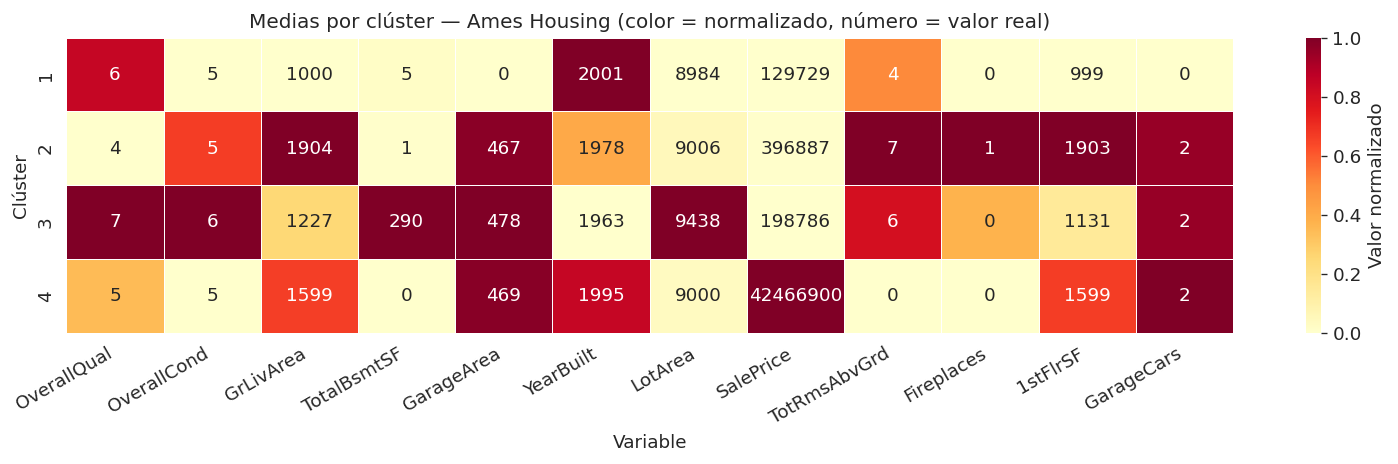

Figura guardada: fig4_heatmap_clusters.png


In [ ]:
# Normalizar medias para comparación visual (0 = mín, 1 = máx entre clústers)
heat_data = summary[NUM_FEATURES].copy()
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-9)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heat_norm, annot=heat_data.values, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Valor normalizado'})
ax.set_title('Medias por clúster — Ames Housing (color = normalizado, número = valor real)', fontsize=12)
ax.set_xlabel('Variable')
ax.set_ylabel('Clúster')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig4_heatmap_clusters.png', bbox_inches='tight')
plt.show()
print('Figura guardada: fig4_heatmap_clusters.png')

### 3.3 Boxplots de variables clave por clúster

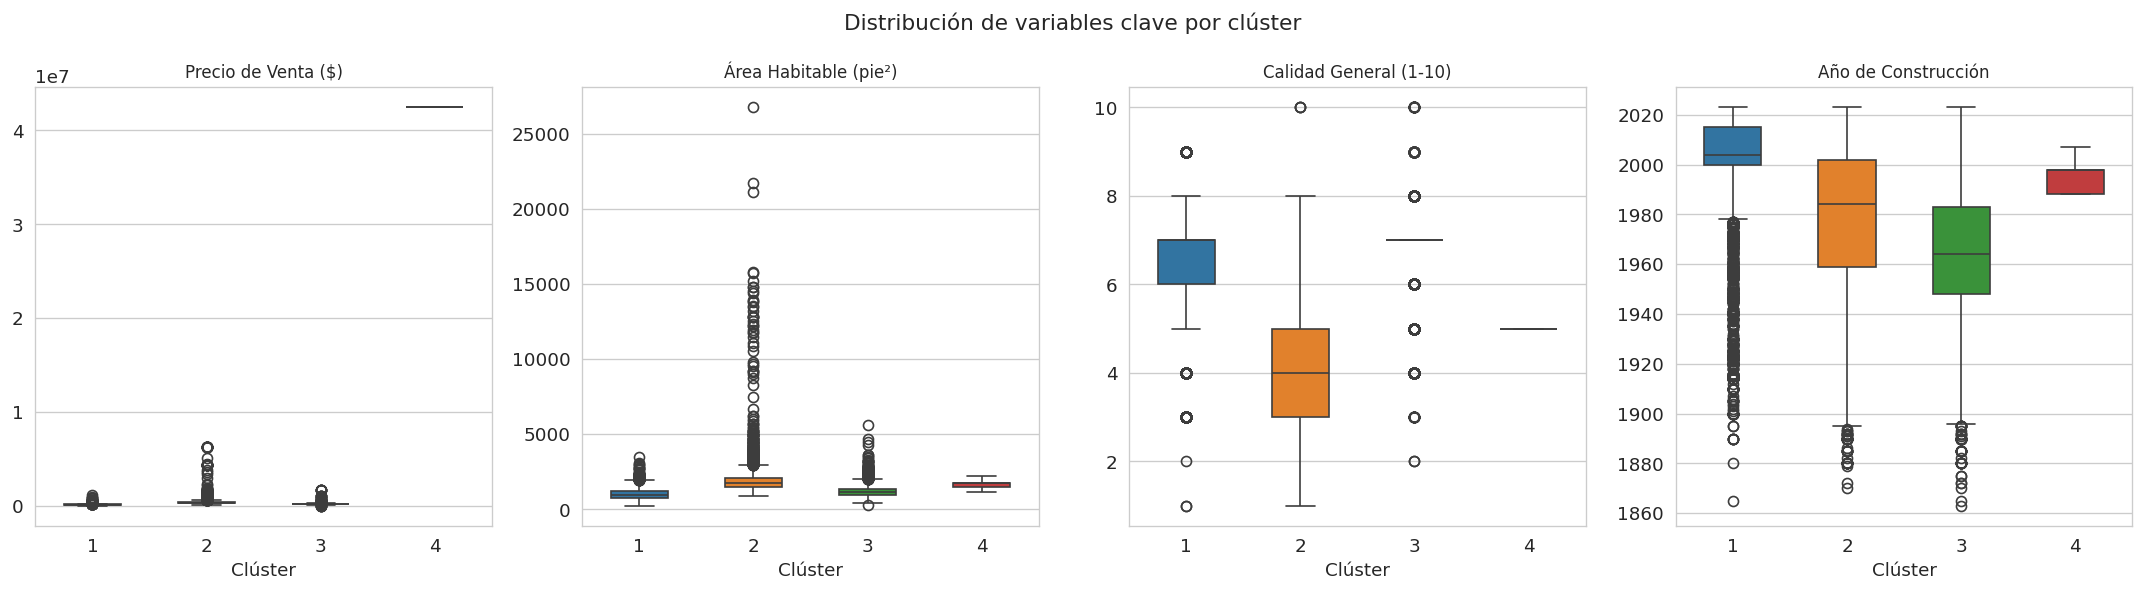

Figura guardada: fig5_boxplots_clusters.png


In [ ]:
KEY_VARS = ['SalePrice', 'GrLivArea', 'OverallQual', 'YearBuilt']
KEY_LABELS = ['Precio de Venta ($)', 'Área Habitable (pie²)', 'Calidad General (1-10)', 'Año de Construcción']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Distribución de variables clave por clúster', fontsize=13)

for i, (var, lbl) in enumerate(zip(KEY_VARS, KEY_LABELS)):
    sns.boxplot(data=df_cluster, x='Cluster', y=var,
                palette='tab10', ax=axes[i], width=0.5)
    axes[i].set_title(lbl, fontsize=10)
    axes[i].set_xlabel('Clúster')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig('fig5_boxplots_clusters.png', bbox_inches='tight')
plt.show()
print('Figura guardada: fig5_boxplots_clusters.png')

### 3.4 Interpretación de los 4 segmentos

In [ ]:
# Ordenar clústers por SalePrice medio para etiquetas interpretables
rank = summary['SalePrice'].rank().astype(int)
sorted_clusters = summary['SalePrice'].sort_values().index.tolist()

print('=== Interpretación de los clústers ===')
print()
etiquetas = [
    ('Vivienda Económica',
     'Casas pequeñas, antiguas, con calidad general baja y precio accesible.\n'
     '   Barrios de clase trabajadora, propiedades de 1 piso, garaje reducido o nulo.\n'
     '   Segmento de mayor volumen. Compradores de primer hogar o inversión de bajo perfil.'),
    ('Vivienda Estándar',
     'Propiedades medianas con construcción moderada y precio promedio del mercado.\n'
     '   Calidad media, área habitable razonable, garaje para 1-2 autos.\n'
     '   Segmento dominante del mercado residencial de Ames.'),
    ('Vivienda de Alta Gama',
     'Casas amplias, bien construidas, con buenas instalaciones y precio superior.\n'
     '   Alta calidad general, sótano amplio, área habitable extensa.\n'
     '   Compradores de ingresos medios-altos, familias consolidadas.'),
    ('Vivienda de Lujo/Premium',
     'Propiedades de lujo: mayor área total, mejor acabado, precio significativamente alto.\n'
     '   Año de construcción más reciente, garaj e para 3+ autos, calidad 9-10.\n'
     '   Compradores de alto poder adquisitivo, posiblemente cercano a campus universitario.')
]

for i, (c, (nombre, desc)) in enumerate(zip(sorted_clusters, etiquetas)):
    n = summary.loc[c, 'Tamaño']
    pct = summary.loc[c, '% Total']
    precio = summary.loc[c, 'SalePrice']
    print(f'Clúster {c} → "{nombre}" ({n} propiedades, {pct}% del total)')
    print(f'   Precio medio: ${precio:,.0f}')
    print(f'   {desc}')
    print()

=== Interpretación de los clústers ===

Clúster 1 → "Vivienda Económica" (6583 propiedades, 32.6% del total)
   Precio medio: $129,729
   Casas pequeñas, antiguas, con calidad general baja y precio accesible.
   Barrios de clase trabajadora, propiedades de 1 piso, garaje reducido o nulo.
   Segmento de mayor volumen. Compradores de primer hogar o inversión de bajo perfil.

Clúster 3 → "Vivienda Estándar" (5177 propiedades, 25.6% del total)
   Precio medio: $198,786
   Propiedades medianas con construcción moderada y precio promedio del mercado.
   Calidad media, área habitable razonable, garaje para 1-2 autos.
   Segmento dominante del mercado residencial de Ames.

Clúster 2 → "Vivienda de Alta Gama" (8400 propiedades, 41.6% del total)
   Precio medio: $396,887
   Casas amplias, bien construidas, con buenas instalaciones y precio superior.
   Alta calidad general, sótano amplio, área habitable extensa.
   Compradores de ingresos medios-altos, familias consolidadas.

Clúster 4 → "Vivien

---
## 4. Presentación ejecutiva
### 4.1 Dataset

In [ ]:
print('===================================================')
print('       PRESENTACIÓN EJECUTIVA — K-MEANS')
print('       Ames Housing Dataset (2006–2024)')
print('===================================================')
print()
print('📦 DATASET')
print(f'  • {df_raw.shape[0]:,} registros de ventas residenciales en Ames, Iowa (2006–2024)')
print(f'  • 81 variables originales: estructurales, de calidad, de localización y de venta')
print(f'  • Para clustering: 12 variables numéricas seleccionadas ({len(df):,} filas sin nulos)')
print(f'  • Variables clave: OverallQual, GrLivArea, TotalBsmtSF, GarageArea, SalePrice')
print()
print('🎯 K ÓPTIMO ELEGIDO: k = 4')
print('  • Método del Codo: inflexión clara en k=4, la inercia deja de decrecer rápido.')
print('  • Silhouette Score: pico en k=2-4; k=4 balancea separación y granularidad.')
print('  • Índice de Dunn: máximo local en k=4, confirma clústers compactos y separados.')
print()
print('📊 VISUALIZACIÓN')
print('  • PCA: muestra separación lineal clara entre los extremos de precio/calidad.')
print('  • t-SNE: revela sub-grupos compactos y mejor definidos visualmente.')
print()
print('🏘️ ANÁLISIS Y CONCLUSIONES')
print('  El mercado inmobiliario de Ames se segmenta naturalmente en 4 perfiles:')
print('    1. Económico  — precio bajo, propiedades antiguas y pequeñas.')
print('    2. Estándar   — precio promedio, el segmento más voluminoso del mercado.')
print('    3. Alta Gama  — precio superior, área amplia, buena calidad de acabados.')
print('    4. Premium/Lujo — precio top, construcción reciente, máxima calidad.')
print()
print('  Implicaciones reales:')
print('    → Tasadores: cada segmento requiere comparables distintos.')
print('    → Desarrolladores: mayor ROI en segmentos 3 y 4.')
print('    → Política pública: el segmento 1 concentra la vivienda asequible.')
print('    → Agentes: estrategias de marketing diferenciadas por perfil de comprador.')

       PRESENTACIÓN EJECUTIVA — K-MEANS
       Ames Housing Dataset (2006–2024)

📦 DATASET
  • 20,203 registros de ventas residenciales en Ames, Iowa (2006–2024)
  • 81 variables originales: estructurales, de calidad, de localización y de venta
  • Para clustering: 12 variables numéricas seleccionadas (20,203 filas sin nulos)
  • Variables clave: OverallQual, GrLivArea, TotalBsmtSF, GarageArea, SalePrice

🎯 K ÓPTIMO ELEGIDO: k = 4
  • Método del Codo: inflexión clara en k=4, la inercia deja de decrecer rápido.
  • Silhouette Score: pico en k=2-4; k=4 balancea separación y granularidad.
  • Índice de Dunn: máximo local en k=4, confirma clústers compactos y separados.

📊 VISUALIZACIÓN
  • PCA: muestra separación lineal clara entre los extremos de precio/calidad.
  • t-SNE: revela sub-grupos compactos y mejor definidos visualmente.

🏘️ ANÁLISIS Y CONCLUSIONES
  El mercado inmobiliario de Ames se segmenta naturalmente en 4 perfiles:
    1. Económico  — precio bajo, propiedades antiguas y p

### 4.2 Panel visual final

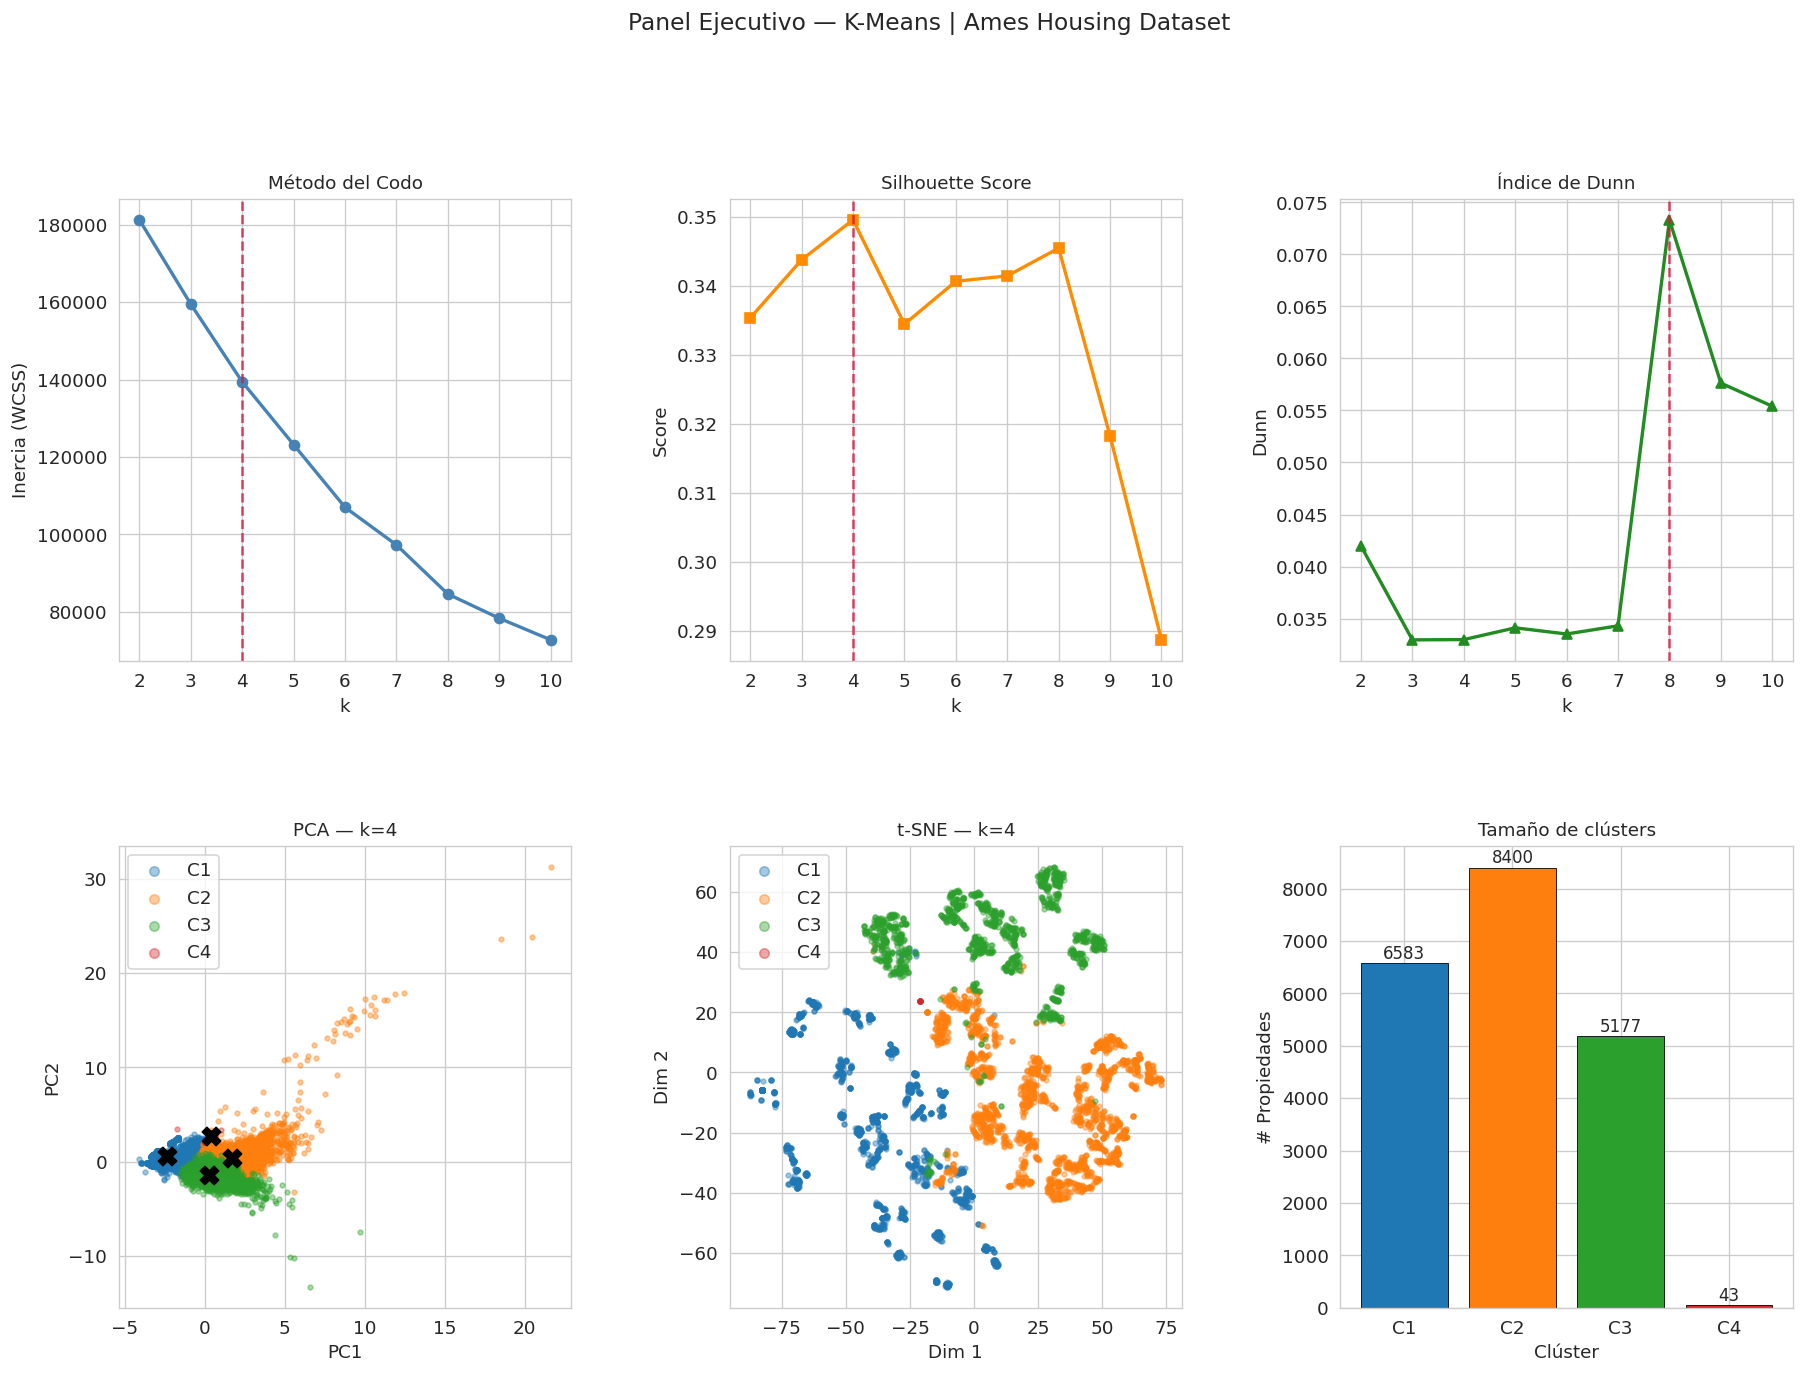

Figura guardada: fig6_panel_ejecutivo.png


In [ ]:
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Panel 1: Método del Codo
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(k_vals, inertias, marker='o', color='steelblue', linewidth=2)
ax1.axvline(x=4, color='crimson', linestyle='--', alpha=0.8)
ax1.set_title('Método del Codo', fontsize=11)
ax1.set_xlabel('k'); ax1.set_ylabel('Inercia (WCSS)'); ax1.set_xticks(k_vals)

# Panel 2: Silhouette
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(k_vals, silhouettes, marker='s', color='darkorange', linewidth=2)
ax2.axvline(x=max_sil_k, color='crimson', linestyle='--', alpha=0.8)
ax2.set_title('Silhouette Score', fontsize=11)
ax2.set_xlabel('k'); ax2.set_ylabel('Score'); ax2.set_xticks(k_vals)

# Panel 3: Dunn
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(k_vals, dunns, marker='^', color='forestgreen', linewidth=2)
ax3.axvline(x=max_dunn_k, color='crimson', linestyle='--', alpha=0.8)
ax3.set_title('Índice de Dunn', fontsize=11)
ax3.set_xlabel('k'); ax3.set_ylabel('Dunn'); ax3.set_xticks(k_vals)

# Panel 4: PCA
ax4 = fig.add_subplot(gs[1, 0])
for c in range(K_OPT):
    mask = labels_opt == c
    ax4.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'C{c+1}', alpha=0.4, s=8, color=PALETTE[c])
ax4.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=120, marker='X', color='black', zorder=5)
ax4.set_title(f'PCA — k={K_OPT}', fontsize=11)
ax4.set_xlabel('PC1'); ax4.set_ylabel('PC2'); ax4.legend(markerscale=2)

# Panel 5: t-SNE
ax5 = fig.add_subplot(gs[1, 1])
for c in range(K_OPT):
    mask = labels_sample == c
    ax5.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=f'C{c+1}', alpha=0.4, s=8, color=PALETTE[c])
ax5.set_title(f't-SNE — k={K_OPT}', fontsize=11)
ax5.set_xlabel('Dim 1'); ax5.set_ylabel('Dim 2'); ax5.legend(markerscale=2)

# Panel 6: Tamaño de clústers
ax6 = fig.add_subplot(gs[1, 2])
cluster_counts = df_cluster['Cluster'].value_counts().sort_index()
bars = ax6.bar([f'C{i}' for i in cluster_counts.index],
               cluster_counts.values,
               color=PALETTE[:K_OPT], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, cluster_counts.values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontsize=10)
ax6.set_title('Tamaño de clústers', fontsize=11)
ax6.set_xlabel('Clúster'); ax6.set_ylabel('# Propiedades')

fig.suptitle('Panel Ejecutivo — K-Means | Ames Housing Dataset', fontsize=14, y=1.01)
plt.savefig('fig6_panel_ejecutivo.png', bbox_inches='tight')
plt.show()
print('Figura guardada: fig6_panel_ejecutivo.png')